In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

B_RESULTS_CSV_PATH = "B_results.csv"


I_POS_mA = +10.0
I_NEG_mA = -10.0

I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

mu0 = 4 * np.pi * 1e-7  # T m / A

#lab frame:
#   x = magnet line / horizontal image axis
#   y = approximate wire direction / vertical image axis
#   z = optical axis

# Wire mostly along +y, with possible small tilt toward +x.
WIRE_THETA_DEG = 5.0       # angle from +y toward +x
WIRE_X0_UM = 0.0
WIRE_Y0_UM = 0.0

# Effective sensor depth.
# Start at 10 µm because NV layer thickness is 20 µm and midpoint is 10 µm.
SENSOR_DEPTH_UM = 10.0

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"

print("Simulation setup")
print("----------------")
print("I_POS_mA:", I_POS_mA)
print("I_NEG_mA:", I_NEG_mA)
print("SENSOR_DEPTH_UM:", SENSOR_DEPTH_UM)
print("WIRE_THETA_DEG:", WIRE_THETA_DEG)
print("WIRE_X0_UM:", WIRE_X0_UM)
print("WIRE_Y0_UM:", WIRE_Y0_UM)

Simulation setup
----------------
I_POS_mA: 10.0
I_NEG_mA: -10.0
SENSOR_DEPTH_UM: 10.0
WIRE_THETA_DEG: 5.0
WIRE_X0_UM: 0.0
WIRE_Y0_UM: 0.0


In [19]:
# load B-results fiel

B_df = pd.read_csv(B_RESULTS_CSV_PATH)

required_cols = [
    "pixel", "row", "col", "x_um", "y_um",
    "Bx_pos_nT", "By_pos_nT", "Bz_pos_nT",
    "Bx_neg_nT", "By_neg_nT", "Bz_neg_nT",
]

missing = [c for c in required_cols if c not in B_df.columns]
if missing:
    raise ValueError(f"B_results.csv is missing columns: {missing}")

B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

B_pos_meas = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_meas = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

print("Loaded measured data")
print("grid:", grid_size, "x", grid_size)
print("extent_um:", extent_um)

if "POS_time_actual_s" in B_df.columns:
    print("POS time [s]:", B_df["POS_time_actual_s"].iloc[0])
if "NEG_time_actual_s" in B_df.columns:
    print("NEG time [s]:", B_df["NEG_time_actual_s"].iloc[0])


Loaded measured data
grid: 31 x 31
extent_um: [np.float64(-100.0), np.float64(100.0), np.float64(-100.0), np.float64(100.0)]
POS time [s]: 0.0625968
NEG time [s]: 0.0571872


## Infinite straight wire model

SI units internally:
   x,y,z in meters
   I in amperes
   B in tesla 
 Output:  B in nT


In [20]:

# Tilted infinite-wire Biot-Savart model

def simulate_tilted_wire(
    x_um,
    y_um,
    I_A,
    depth_um,
    x0_um=0.0,
    y0_um=0.0,
    theta_deg=0.0,
):
    """
    Infinite straight wire in the xy plane.

    Lab frame:
        x = horizontal image axis / magnet line
        y = vertical image axis / approximate wire direction
        z = optical axis

    Wire direction:
        theta_deg = 0 means wire along +y.
        theta_deg > 0 tilts the wire toward +x as y increases.

    Returns:
        B_nT with shape (3, Ny, Nx), order [Bx, By, Bz].
    """

    theta = np.deg2rad(theta_deg)

    ux = np.sin(theta)
    uy = np.cos(theta)
    uz = 0.0

    X = (x_um - x0_um) * 1e-6
    Y = (y_um - y0_um) * 1e-6
    Z = depth_um * 1e-6 * np.ones_like(X)

    Rx = X
    Ry = Y
    Rz = Z

    u_dot_R = ux * Rx + uy * Ry + uz * Rz

    rho_x = Rx - ux * u_dot_R
    rho_y = Ry - uy * u_dot_R
    rho_z = Rz - uz * u_dot_R

    rho2 = rho_x**2 + rho_y**2 + rho_z**2
    rho2 = np.where(rho2 < 1e-30, 1e-30, rho2)

    cross_x = uy * rho_z - uz * rho_y
    cross_y = uz * rho_x - ux * rho_z
    cross_z = ux * rho_y - uy * rho_x

    prefactor = mu0 * I_A / (2 * np.pi * rho2)

    Bx_T = prefactor * cross_x
    By_T = prefactor * cross_y
    Bz_T = prefactor * cross_z

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

In [21]:
#simulate POS and NEG maps

B_pos_sim = simulate_tilted_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    depth_um=SENSOR_DEPTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
)

B_neg_sim = simulate_tilted_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    depth_um=SENSOR_DEPTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
)

print("Simulated POS and NEG maps")
for i, comp in enumerate(B_COMPONENTS):
    print(comp, "POS p95 [nT] =", np.nanpercentile(np.abs(B_pos_sim[i]), 95))

Simulated POS and NEG maps
Bx POS p95 [nT] = 156454.7530930767
By POS p95 [nT] = 13688.017250391704
Bz POS p95 [nT] = 96591.68981865636


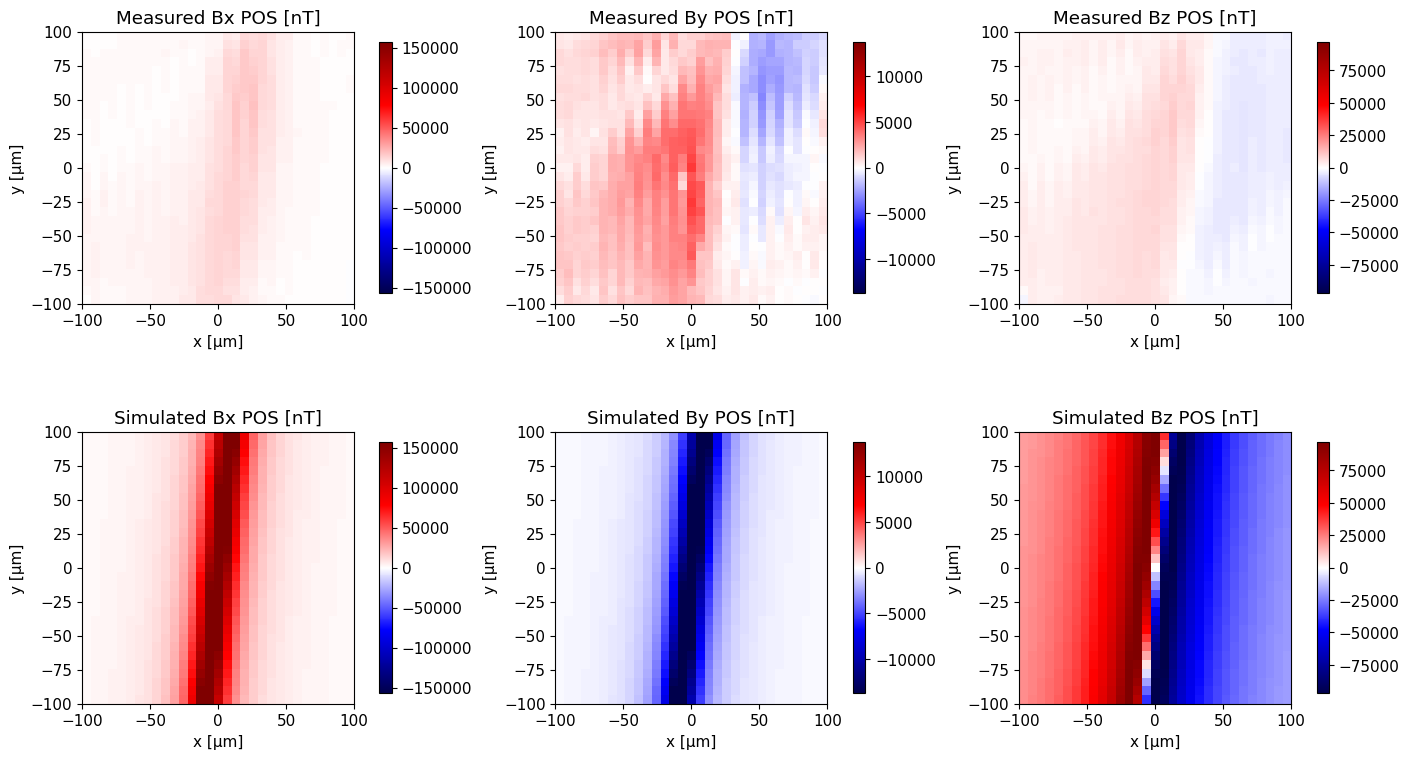

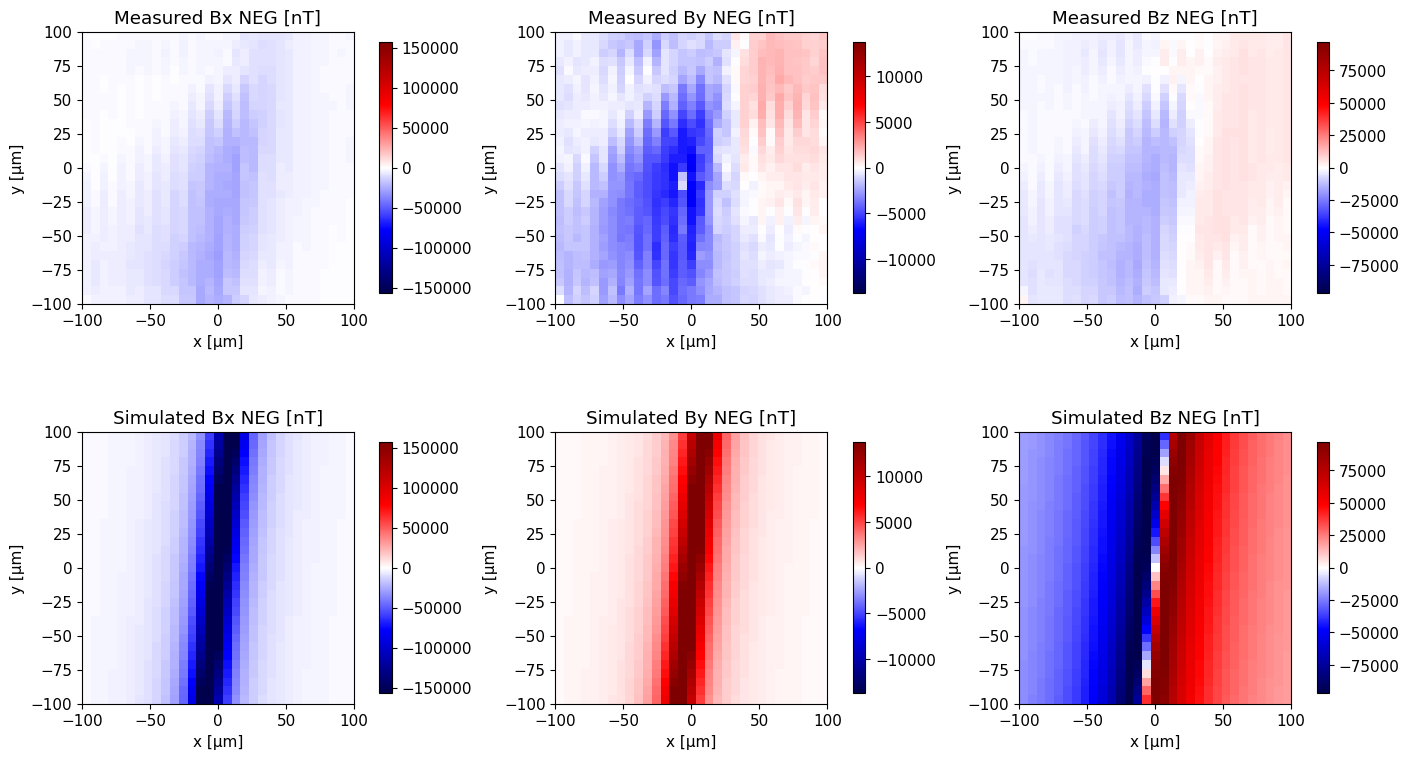

In [22]:
#plot measureds vs simulated 

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        np.nanpercentile(np.abs(B_pos_sim[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Measured {comp} POS [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    im1 = axes[1, i].imshow(
        B_pos_sim[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Simulated {comp} POS [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.show()

#NEgative
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_neg_meas[i]), 95),
        np.nanpercentile(np.abs(B_neg_sim[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_neg_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Measured {comp} NEG [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    im1 = axes[1, i].imshow(
        B_neg_sim[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Simulated {comp} NEG [nT]")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.show()

In [23]:
# ============================================================
# Direct measured-vs-simulated comparison
# ============================================================

comparison_rows = []

for i, comp in enumerate(B_COMPONENTS):
    for phase, meas_map, sim_map in [
        ("POS", B_pos_meas[i], B_pos_sim[i]),
        ("NEG", B_neg_meas[i], B_neg_sim[i]),
    ]:
        meas = meas_map.ravel()
        sim = sim_map.ravel()

        mask = np.isfinite(meas) & np.isfinite(sim)

        if np.nanstd(meas[mask]) > 0 and np.nanstd(sim[mask]) > 0:
            corr = np.corrcoef(meas[mask], sim[mask])[0, 1]
        else:
            corr = np.nan

        rms_res = np.sqrt(np.nanmean((meas[mask] - sim[mask])**2))

        comparison_rows.append({
            "component": comp,
            "phase": phase,
            "measured_p95_abs_nT": np.nanpercentile(np.abs(meas), 95),
            "simulated_p95_abs_nT": np.nanpercentile(np.abs(sim), 95),
            "rms_residual_nT": rms_res,
            "corr_meas_sim": corr,
        })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,component,phase,measured_p95_abs_nT,simulated_p95_abs_nT,rms_residual_nT,corr_meas_sim
0,Bx,POS,13433.715457,156454.753093,50404.988056,0.674238
1,Bx,NEG,24199.039109,156454.753093,47489.227575,0.681033
2,By,POS,3673.775926,13688.017250,6246.342794,-0.584826
3,By,NEG,5308.921674,13688.017250,6792.348224,-0.598332
4,Bz,POS,7395.124460,96591.689819,50699.303114,0.318745
5,Bz,NEG,13584.200569,96591.689819,49508.115360,0.441782


In [24]:
# ============================================================
# Scan effective wire-to-NV distance
# ============================================================
# Current is kept fixed at +/- 10 mA.
# Only effective sensing depth is varied.
# ============================================================

depth_values_um = np.array([10, 15, 20, 30, 40, 50, 75, 100, 150], dtype=float)

scan_rows = []

for depth_um in depth_values_um:
    Bp = simulate_tilted_wire(
        x_grid_um,
        y_grid_um,
        I_A=I_POS_A,
        depth_um=depth_um,
        x0_um=WIRE_X0_UM,
        y0_um=WIRE_Y0_UM,
        theta_deg=WIRE_THETA_DEG,
    )

    Bn = simulate_tilted_wire(
        x_grid_um,
        y_grid_um,
        I_A=I_NEG_A,
        depth_um=depth_um,
        x0_um=WIRE_X0_UM,
        y0_um=WIRE_Y0_UM,
        theta_deg=WIRE_THETA_DEG,
    )

    for i, comp in enumerate(B_COMPONENTS):
        for phase, meas_map, sim_map in [
            ("POS", B_pos_meas[i], Bp[i]),
            ("NEG", B_neg_meas[i], Bn[i]),
        ]:
            meas = meas_map.ravel()
            sim = sim_map.ravel()

            mask = np.isfinite(meas) & np.isfinite(sim)

            if np.nanstd(meas[mask]) > 0 and np.nanstd(sim[mask]) > 0:
                corr = np.corrcoef(meas[mask], sim[mask])[0, 1]
            else:
                corr = np.nan

            rms_res = np.sqrt(np.nanmean((meas[mask] - sim[mask])**2))

            scan_rows.append({
                "depth_um": depth_um,
                "component": comp,
                "phase": phase,
                "measured_p95_abs_nT": np.nanpercentile(np.abs(meas), 95),
                "simulated_p95_abs_nT": np.nanpercentile(np.abs(sim), 95),
                "rms_residual_nT": rms_res,
                "corr_meas_sim": corr,
            })

depth_scan_df = pd.DataFrame(scan_rows)
display(depth_scan_df)

summary_depth_df = (
    depth_scan_df
    .groupby("depth_um", as_index=False)
    .agg(
        mean_abs_corr=("corr_meas_sim", lambda x: np.nanmean(np.abs(x))),
        mean_rms_residual_nT=("rms_residual_nT", "mean"),
    )
)

display(summary_depth_df)

best_depth_by_corr = summary_depth_df.loc[
    summary_depth_df["mean_abs_corr"].idxmax()
]

best_depth_by_rms = summary_depth_df.loc[
    summary_depth_df["mean_rms_residual_nT"].idxmin()
]

print("Best depth by mean |correlation|:")
display(best_depth_by_corr)

print("Best depth by mean RMS residual:")
display(best_depth_by_rms)

,depth_um,component,phase,measured_p95_abs_nT,simulated_p95_abs_nT,rms_residual_nT,corr_meas_sim
0,10.0,Bx,POS,13433.715457,156454.753093,50404.988056,0.674238
1,10.0,Bx,NEG,24199.039109,156454.753093,47489.227575,0.681033
2,10.0,By,POS,3673.775926,13688.017250,6246.342794,-0.584826
3,10.0,By,NEG,5308.921674,13688.017250,6792.348224,-0.598332
4,10.0,Bz,POS,7395.124460,96591.689819,50699.303114,0.318745
5,10.0,Bz,NEG,13584.200569,96591.689819,49508.115360,0.441782
6,15.0,Bx,POS,13433.715457,118431.976981,39783.240196,0.745935
7,15.0,Bx,NEG,24199.039109,118431.976981,36571.661952,0.746093
8,15.0,By,POS,3673.775926,10361.455385,5435.853985,-0.615677
9,15.0,By,NEG,5308.921674,10361.455385,6025.107131,-0.645430


,depth_um,mean_abs_corr,mean_rms_residual_nT
0,10.0,0.549826,35190.054187
1,15.0,0.608914,27592.874687
2,20.0,0.640670,23000.896406
3,30.0,0.664951,17503.576955
4,40.0,0.666124,14219.377327
5,50.0,0.658814,11992.086590
6,75.0,0.633586,8628.026794
7,100.0,0.612731,6803.783228
8,150.0,0.587776,5138.259184


Best depth by mean |correlation|:


depth_um                   40.000000
mean_abs_corr               0.666124
mean_rms_residual_nT    14219.377327
Name: 4, dtype: float64

Best depth by mean RMS residual:


depth_um                 150.000000
mean_abs_corr              0.587776
mean_rms_residual_nT    5138.259184
Name: 8, dtype: float64

Using BEST_DEPTH_UM = 150.0


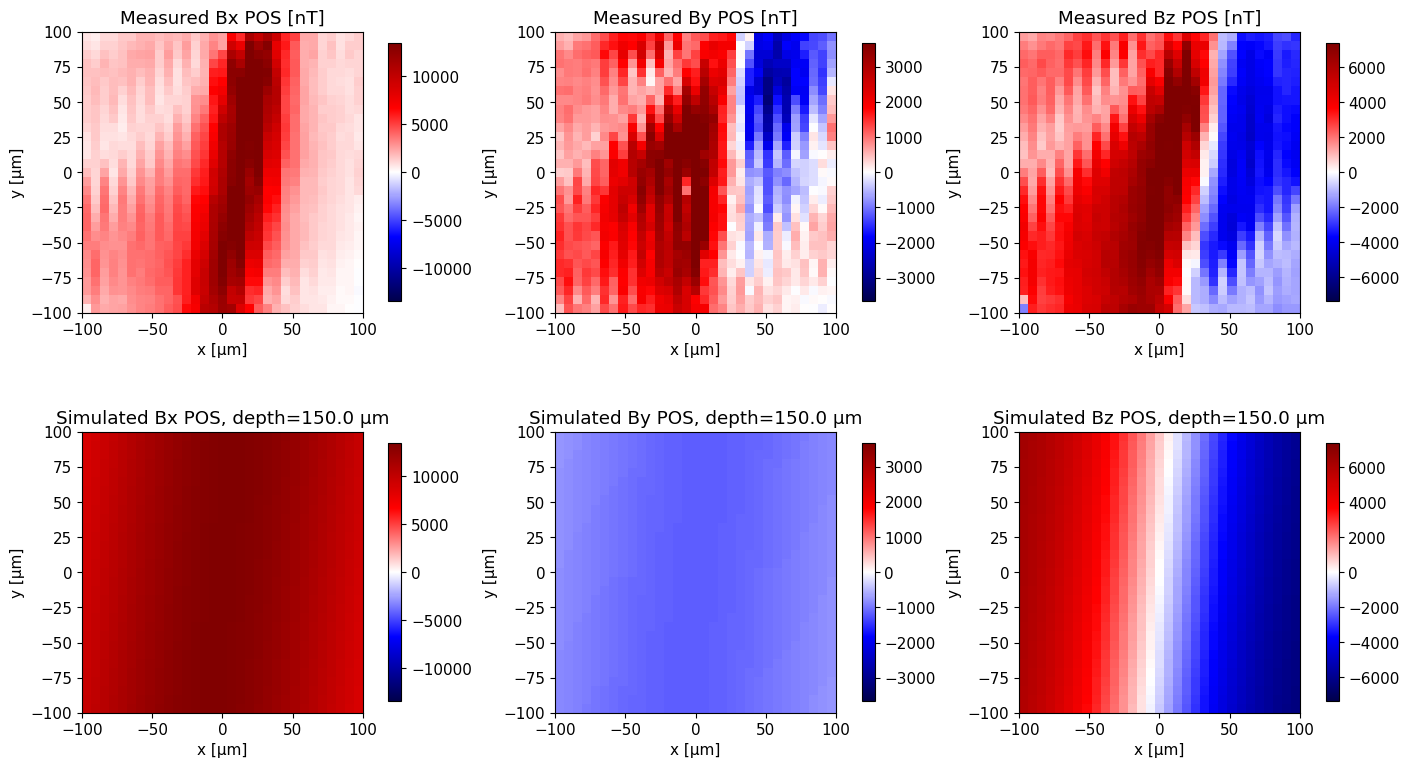

In [25]:
# ============================================================
# Replot using selected effective depth
# ============================================================

BEST_DEPTH_UM = float(best_depth_by_rms["depth_um"])

B_pos_sim_best = simulate_tilted_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_POS_A,
    depth_um=BEST_DEPTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
)

B_neg_sim_best = simulate_tilted_wire(
    x_grid_um,
    y_grid_um,
    I_A=I_NEG_A,
    depth_um=BEST_DEPTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    theta_deg=WIRE_THETA_DEG,
)

print("Using BEST_DEPTH_UM =", BEST_DEPTH_UM)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    lim = max(
        np.nanpercentile(np.abs(B_pos_meas[i]), 95),
        np.nanpercentile(np.abs(B_pos_sim_best[i]), 95),
    )
    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    im0 = axes[0, i].imshow(
        B_pos_meas[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[0, i].set_title(f"Measured {comp} POS [nT]")
    axes[0, i].set_xlabel("x [µm]")
    axes[0, i].set_ylabel("y [µm]")
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)

    im1 = axes[1, i].imshow(
        B_pos_sim_best[i],
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    axes[1, i].set_title(f"Simulated {comp} POS, depth={BEST_DEPTH_UM:.1f} µm")
    axes[1, i].set_xlabel("x [µm]")
    axes[1, i].set_ylabel("y [µm]")
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.show()